#Avaliação G1 — Projeto de Análise e Visualização de Dados com Python
##Tema: Indicadores de Saúde Pública no Brasil
###Disciplina: Linguagens de Programação
###Professor: Alexandre Neves Louzada
###Aluno: João Pedro de Farias Torres de Souza

---
## 1. Introdução

Este projeto tem como objetivo realizar uma análise e visualização de dados relacionados à saúde pública no Brasil, no período de 2015 a 2024.

A partir desses dados, serão realizadas análises exploratórias, temporais e comparativas entre regiões e estados, buscando identificar padrões e diferenças nos indicadores apresentados pela base.

---
## 2. Contextualização

Os indicadores de saúde pública são utilizados para analisar diferentes aspectos relacionados às condições de saúde da população.

A base utilizada neste projeto contempla indicadores relacionados a:

- mortalidade;
- internações;
- vacinação;
- expectativa de vida;
- doenças crônicas;
- infraestrutura hospitalar;
- disponibilidade de médicos;
- nível de criticidade.

A análise desses indicadores permite observar sua evolução ao longo do tempo e realizar comparações entre diferentes regiões e estados presentes na base de dados.

O projeto considera o período de 2015 a 2024 e busca analisar a evolução dos indicadores, identificar diferenças regionais, investigar tendências temporais, avaliar aspectos da infraestrutura hospitalar e construir um dashboard interativo.

---
## 3. Explicação da base

A base utilizada neste projeto é o arquivo:

`simulacao_saude_publica_brasil.csv`

Trata-se de um dataset simulado contendo informações relacionadas a indicadores de saúde pública no Brasil. A base apresenta informações temporais, geográficas e indicadores relacionados às condições de saúde e à infraestrutura hospitalar.

As principais variáveis disponíveis são:

| Coluna | Descrição |
|---|---|
| `ano` | Ano da medição |
| `mes` | Mês da medição |
| `data` | Data de referência |
| `regiao` | Região do Brasil |
| `uf` | Estado |
| `municipio` | Município |
| `expectativa_vida` | Expectativa de vida |
| `taxa_mortalidade` | Taxa de mortalidade |
| `taxa_internacao` | Taxa de internação |
| `cobertura_vacinal` | Percentual de vacinação |
| `medicos_por_1000` | Quantidade de médicos |
| `leitos_hospitalares` | Quantidade de leitos |
| `casos_doencas_cronicas` | Quantidade estimada de casos |
| `nivel_criticidade` | Classificação em Baixo, Médio, Alto ou Crítico |

---
## 4. Leitura dos Dados

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
#Verificando se o arquivo com os dados está presente
CAMINHO = Path("../dados/simulacao_saude_publica_brasil.csv")

if not CAMINHO.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {CAMINHO}")

print(f"Arquivo encontrado: {CAMINHO}")

Arquivo encontrado: ../dados/simulacao_saude_publica_brasil.csv


In [3]:
df = pd.read_csv(CAMINHO)

df.head()

,ano,mes,data,regiao,uf,municipio,expectativa_vida,taxa_mortalidade,taxa_internacao,cobertura_vacinal,medicos_por_1000,leitos_hospitalares,casos_doencas_cronicas,nivel_criticidade
0,2015,1,2015-01-01,Norte,AM,Manaus,69.9,7.25,59.37,55.88,2.30,566,56400,Alto
1,2015,1,2015-01-01,Norte,PA,Belém,71.6,6.10,100.28,68.56,0.94,9478,90326,Baixo
2,2015,1,2015-01-01,Norte,PA,Santarém,76.8,11.05,80.91,57.28,3.68,6539,199254,Alto
3,2015,1,2015-01-01,Norte,RO,Porto Velho,70.7,4.32,76.32,76.93,3.76,6025,126939,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,71.1,5.60,70.61,51.93,3.52,2957,170250,Alto


In [4]:
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de registros: 4440
Quantidade de colunas: 14


Inspecionando os dados

In [5]:
'''
Verificando dados:
- quantidade de registros;
- nomes das colunas;
- tipos das variáveis;
- existência de valores não nulos.
'''

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ano                     4440 non-null   int64  
 1   mes                     4440 non-null   int64  
 2   data                    4440 non-null   object 
 3   regiao                  4440 non-null   object 
 4   uf                      4440 non-null   object 
 5   municipio               4440 non-null   object 
 6   expectativa_vida        4440 non-null   float64
 7   taxa_mortalidade        4440 non-null   float64
 8   taxa_internacao         4440 non-null   float64
 9   cobertura_vacinal       4440 non-null   float64
 10  medicos_por_1000        4440 non-null   float64
 11  leitos_hospitalares     4440 non-null   int64  
 12  casos_doencas_cronicas  4440 non-null   int64  
 13  nivel_criticidade       4440 non-null   object 
dtypes: float64(5), int64(4), object(5)
memor

In [6]:
#Verificando as quantidades de linhas e colunas (valor esperado são de 4440 e 14, respectivamente)
linhas, colunas = df.shape

print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")

Linhas: 4440
Colunas: 14


In [7]:
#Verificando os nomes das colunas
print("Colunas disponíveis:")
for coluna in df.columns:
    print(f"- {coluna}")

Colunas disponíveis:
- ano
- mes
- data
- regiao
- uf
- municipio
- expectativa_vida
- taxa_mortalidade
- taxa_internacao
- cobertura_vacinal
- medicos_por_1000
- leitos_hospitalares
- casos_doencas_cronicas
- nivel_criticidade


In [8]:
#Verificando valores nulos
total_nulos = df.isnull().sum().sum()

print(f"Total de valores nulos: {total_nulos}")

Total de valores nulos: 0


In [9]:
#Verificando linhas duplicadas
total_duplicados = df.duplicated().sum()

print(f"Total de registros duplicados: {total_duplicados}")

Total de registros duplicados: 0


In [10]:
#Dados estatísticos
df.describe()

,ano,mes,expectativa_vida,taxa_mortalidade,taxa_internacao,cobertura_vacinal,medicos_por_1000,leitos_hospitalares,casos_doencas_cronicas
count,4440.000000,4440.000000,4440.00000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000
mean,2019.500000,6.500000,73.47500,7.982655,110.688939,73.710505,2.376187,5963.407658,101285.151126
std,2.872605,3.452441,3.15604,2.351481,40.481913,13.924320,0.917541,3421.481941,57587.446563
min,2015.000000,1.000000,68.00000,4.010000,40.100000,50.000000,0.800000,103.000000,1037.000000
25%,2017.000000,3.750000,70.70000,5.907500,75.537500,61.515000,1.580000,2976.250000,50911.500000
50%,2019.500000,6.500000,73.40000,8.020000,111.505000,73.705000,2.360000,5918.000000,102154.500000
75%,2022.000000,9.250000,76.20000,10.050000,145.692500,85.512500,3.170000,8927.000000,150505.750000
max,2024.000000,12.000000,79.00000,12.000000,180.000000,97.980000,4.000000,11997.000000,199999.000000


---
## 5. Limpeza e preparação
  - conversão de data
  - verificações de consistência
  - engenharia de atributos necessária

In [11]:
df["data"] = pd.to_datetime(df["data"])

df = df.sort_values(
    ["municipio", "data"]
).reset_index(drop=True)

df.head()

,ano,mes,data,regiao,uf,municipio,expectativa_vida,taxa_mortalidade,taxa_internacao,cobertura_vacinal,medicos_por_1000,leitos_hospitalares,casos_doencas_cronicas,nivel_criticidade
0,2015,1,2015-01-01,Centro-Oeste,GO,Aparecida de Goiânia,75.8,6.88,150.76,78.92,2.04,8838,115696,Baixo
1,2015,2,2015-02-01,Centro-Oeste,GO,Aparecida de Goiânia,78.2,8.31,167.91,84.44,2.95,9426,131674,Baixo
2,2015,3,2015-03-01,Centro-Oeste,GO,Aparecida de Goiânia,71.0,4.08,70.61,88.99,2.28,2039,11545,Alto
3,2015,4,2015-04-01,Centro-Oeste,GO,Aparecida de Goiânia,70.2,9.22,132.83,79.74,1.24,5819,144294,Baixo
4,2015,5,2015-05-01,Centro-Oeste,GO,Aparecida de Goiânia,69.3,9.91,129.64,77.45,1.68,1428,186921,Crítico


In [12]:
#Verificando consistência das datas
print("Data inicial:", df["data"].min())
print("Data final:", df["data"].max())

Data inicial: 2015-01-01 00:00:00
Data final: 2024-12-01 00:00:00


---
## 6. Engenharia de Atributos

In [13]:
#Criação de novas colunas para o dataframe a fim de auxiliar na visualização dos dados
df["expectativa_vida_inicial"] = (
    df.groupby("municipio")["expectativa_vida"]
      .transform("first")
)

df["cobertura_vacinal_inicial"] = (
    df.groupby("municipio")["cobertura_vacinal"]
      .transform("first")
)

df["mortalidade_inicial"] = (
    df.groupby("municipio")["taxa_mortalidade"]
      .transform("first")
)

df["casos_cronicos_inicial"] = (
    df.groupby("municipio")["casos_doencas_cronicas"]
      .transform("first")
)

df["internacao_inicial"] = (
    df.groupby("municipio")["taxa_internacao"]
      .transform("first")
)

In [14]:
df["variacao_expectativa_vida"] = (
    df["expectativa_vida"] -
    df["expectativa_vida_inicial"]
)

df["variacao_cobertura_vacinal"] = (
    df["cobertura_vacinal"] -
    df["cobertura_vacinal_inicial"]
)

df["variacao_mortalidade"] = (
    df["taxa_mortalidade"] -
    df["mortalidade_inicial"]
)

df["variacao_casos_cronicos"] = (
    df["casos_doencas_cronicas"] -
    df["casos_cronicos_inicial"]
)

df["variacao_internacao"] = (
    df["taxa_internacao"] -
    df["internacao_inicial"]
)

In [15]:
df.head()

,ano,mes,data,regiao,uf,municipio,expectativa_vida,taxa_mortalidade,taxa_internacao,cobertura_vacinal,...,expectativa_vida_inicial,cobertura_vacinal_inicial,mortalidade_inicial,casos_cronicos_inicial,internacao_inicial,variacao_expectativa_vida,variacao_cobertura_vacinal,variacao_mortalidade,variacao_casos_cronicos,variacao_internacao
0,2015,1,2015-01-01,Centro-Oeste,GO,Aparecida de Goiânia,75.8,6.88,150.76,78.92,...,75.8,78.92,6.88,115696,150.76,0.0,0.00,0.00,0,0.00
1,2015,2,2015-02-01,Centro-Oeste,GO,Aparecida de Goiânia,78.2,8.31,167.91,84.44,...,75.8,78.92,6.88,115696,150.76,2.4,5.52,1.43,15978,17.15
2,2015,3,2015-03-01,Centro-Oeste,GO,Aparecida de Goiânia,71.0,4.08,70.61,88.99,...,75.8,78.92,6.88,115696,150.76,-4.8,10.07,-2.80,-104151,-80.15
3,2015,4,2015-04-01,Centro-Oeste,GO,Aparecida de Goiânia,70.2,9.22,132.83,79.74,...,75.8,78.92,6.88,115696,150.76,-5.6,0.82,2.34,28598,-17.93
4,2015,5,2015-05-01,Centro-Oeste,GO,Aparecida de Goiânia,69.3,9.91,129.64,77.45,...,75.8,78.92,6.88,115696,150.76,-6.5,-1.47,3.03,71225,-21.12


A base de dados utilizada possui 4.440 registros e 14 variáveis relacionadas aos indicadores de saúde pública analisados no projeto.

A inspeção inicial permitiu verificar a estrutura dos dados, seus tipos, valores ausentes, registros duplicados e categorias disponíveis.

Não foram identificados valores ausentes ou registros duplicados na base analisada.

A variável `data` foi convertida para o formato de data, permitindo sua utilização nas análises temporais. Também foram realizadas verificações de consistência entre as informações de ano e mês presentes nas colunas `ano` e `mes` e os respectivos valores obtidos a partir da coluna `data`.

A etapa de engenharia de atributos utilizou os registros temporais disponíveis para criar variáveis de referência e de variação dos principais indicadores. Para cada município, foram identificados os valores iniciais da série e calculadas as respectivas variações ao longo do período analisado. Dessa forma, tornou-se possível analisar não apenas os valores dos indicadores, mas também sua evolução em relação ao início da série.

---
## 7. KPI's Principais
  - Expectativa média de vida
  - Taxa média de mortalidade
  - Cobertura vacinal média
  - Estado mais vulnerável
  - Média de leitos hospitalares
  - Total de internações

In [16]:
#Expectativa média de vida
kpi_expectativa_vida = df["expectativa_vida"].mean()

print(
    f"Expectativa média de vida: "
    f"{kpi_expectativa_vida:.2f}"
)

Expectativa média de vida: 73.47


In [17]:
#Taxa média de mortalidade
kpi_mortalidade = df["taxa_mortalidade"].mean()

print(
    f"Taxa média de mortalidade: "
    f"{kpi_mortalidade:.2f}"
)

Taxa média de mortalidade: 7.98


In [18]:
#Cobertura vacinal média
kpi_vacinacao = df["cobertura_vacinal"].mean()

print(
    f"Cobertura vacinal média: "
    f"{kpi_vacinacao:.2f}%"
)

Cobertura vacinal média: 73.71%


In [19]:
#Estado mais vulnerável (aqui será adotado o nível de criticidade para a análise)
criticidade_uf = (
    df.groupby(["uf", "nivel_criticidade"])
      .size()
      .unstack(fill_value=0)
)

criticidade_uf["total"] = criticidade_uf.sum(axis=1)

criticidade_uf = criticidade_uf.sort_values(
    by="total",
    ascending=False
)
criticidade_uf

nivel_criticidade,Alto,Baixo,Crítico,Médio,total
uf,,,,,
RJ,107,137,130,106,480
MG,76,98,89,97,360
ES,83,100,84,93,360
SP,101,83,76,100,360
SC,49,63,61,67,240
RS,62,69,57,52,240
CE,66,54,62,58,240
BA,67,58,53,62,240
PE,52,66,51,71,240


In [20]:
#Média de leitos hospitalares
kpi_leitos = df["leitos_hospitalares"].mean()

print(
    f"Média de leitos hospitalares: "
    f"{kpi_leitos:.2f}"
)

Média de leitos hospitalares: 5963.41


In [21]:
#Total de internações
kpi_internacao = df["taxa_internacao"].mean()

print(
    f"Taxa média de internação: "
    f"{kpi_internacao:.2f}"
)

Taxa média de internação: 110.69


### Observação sobre o indicador de internações

A base fornecida apresenta a variável `taxa_internacao`, e não uma variável contendo a quantidade absoluta de internações. Dessa forma, não é possível calcular o total de internações a partir da base sem uma informação adicional que não está presente no dataset. Para a análise, foi utilizada a taxa de internação fornecida.

---
## 8. Visualizações

### 8.1. Evolução Temporal

In [22]:
evolucao_anual = (
    df.groupby("ano")
      .agg({
          "expectativa_vida": "mean",
          "taxa_mortalidade": "mean",
          "taxa_internacao": "mean",
          "cobertura_vacinal": "mean"
      })
      .reset_index()
)

evolucao_anual

,ano,expectativa_vida,taxa_mortalidade,taxa_internacao,cobertura_vacinal
0,2015,73.340541,8.054595,109.781081,73.125248
1,2016,73.581757,7.902365,111.506441,73.756914
2,2017,73.608784,7.839910,112.170518,72.873806
3,2018,73.767117,8.120833,109.325045,74.896374
4,2019,73.336486,7.942050,112.013401,73.638108
5,2020,73.613739,8.019707,109.536351,73.219775
6,2021,73.452928,7.916577,111.022523,74.143243
7,2022,73.272748,7.930743,107.605383,73.364977
8,2023,73.561036,8.012342,111.748356,74.538896
9,2024,73.214865,8.087432,112.180293,73.547703


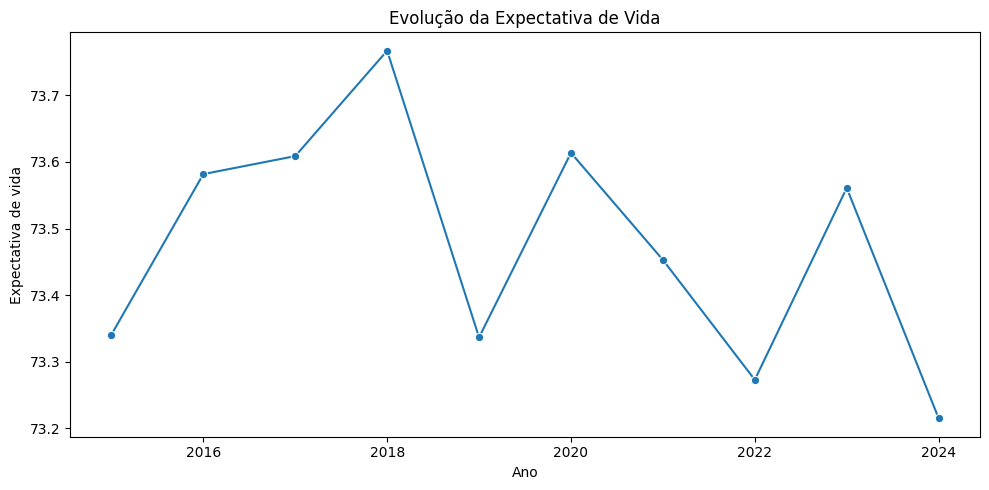

In [23]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=evolucao_anual,
    x="ano",
    y="expectativa_vida",
    marker="o"
)

plt.title("Evolução da Expectativa de Vida")
plt.xlabel("Ano")
plt.ylabel("Expectativa de vida")

plt.tight_layout()
plt.show()

### 8.2. Mortalidade por Estado

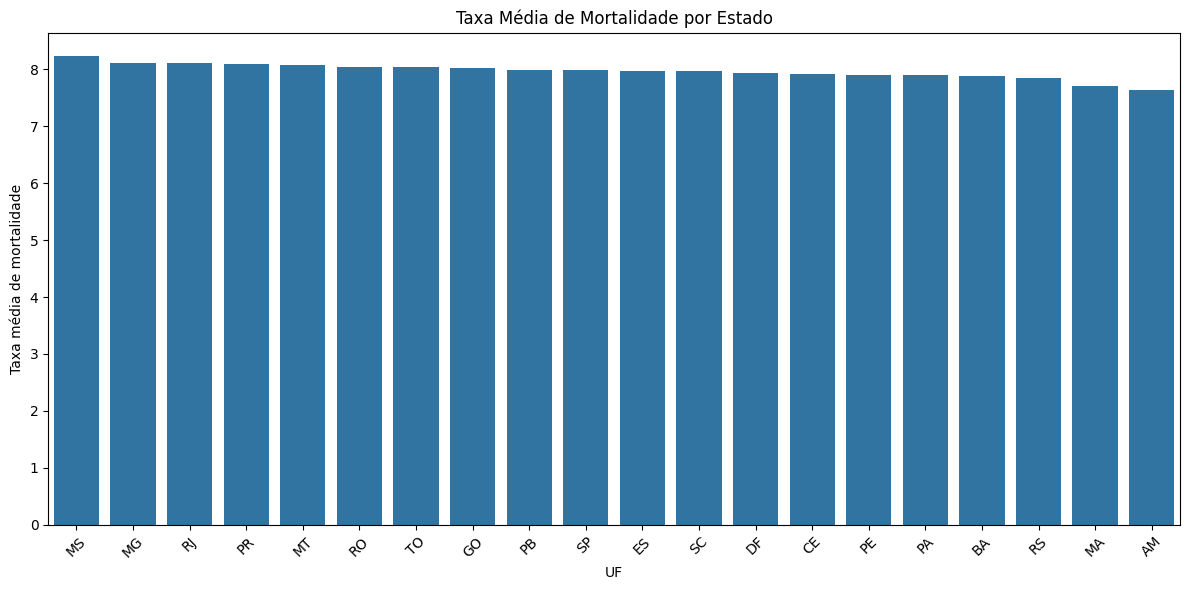

In [24]:
mortalidade_uf = (
    df.groupby("uf")["taxa_mortalidade"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=mortalidade_uf.index,
    y=mortalidade_uf.values
)

plt.title("Taxa Média de Mortalidade por Estado")
plt.xlabel("UF")
plt.ylabel("Taxa média de mortalidade")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 8.3. Infraestrutura Hospitalar

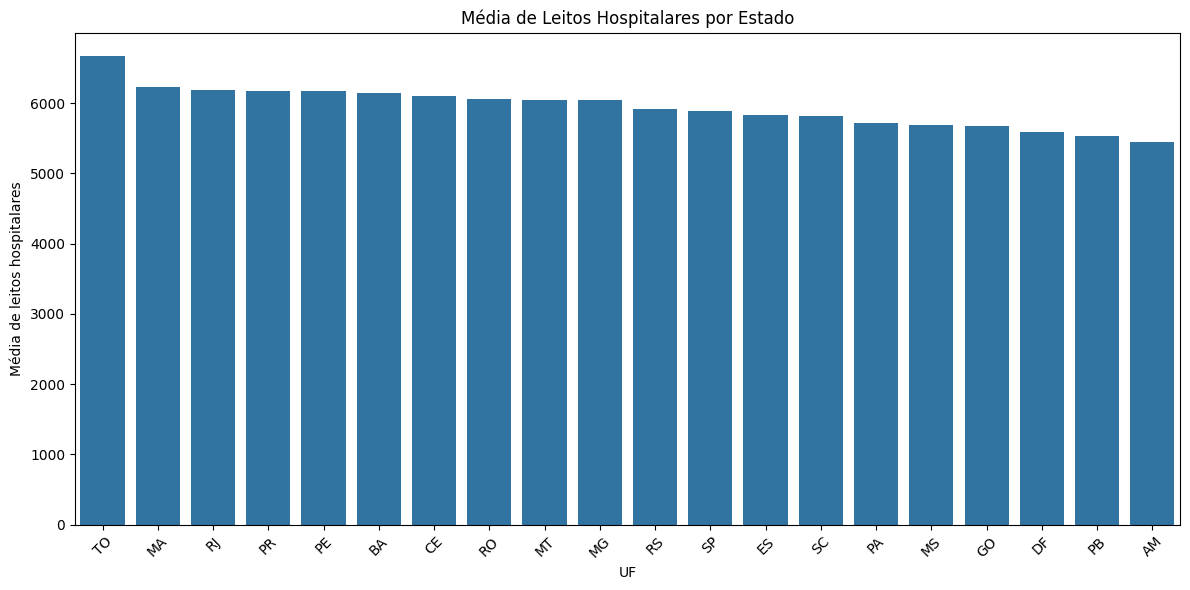

In [25]:
infraestrutura_uf = (
    df.groupby("uf")["leitos_hospitalares"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=infraestrutura_uf.index,
    y=infraestrutura_uf.values
)

plt.title("Média de Leitos Hospitalares por Estado")
plt.xlabel("UF")
plt.ylabel("Média de leitos hospitalares")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [26]:
heatmap_mortalidade = (
    df.groupby(["regiao", "ano"])["taxa_mortalidade"]
      .mean()
      .unstack()
)

heatmap_mortalidade

ano,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
regiao,,,,,,,,,,
Centro-Oeste,8.365500,8.040333,8.017000,7.993000,7.672500,8.580500,8.006000,7.771167,8.046167,8.075167
Nordeste,7.900104,7.993021,8.062083,7.681354,7.743958,8.086771,7.390521,8.135208,7.750729,8.136875
Norte,7.621167,7.334333,8.283500,8.406500,8.903000,7.525333,7.467000,7.574667,7.661333,8.248167
Sudeste,8.173654,7.879231,7.665321,8.389679,7.798718,8.159744,8.208654,7.898141,8.207885,8.107949
Sul,8.104722,8.190000,7.404722,7.992778,7.940556,7.571528,8.285278,8.158472,8.201806,7.853333


### 8.4. Mortalidade por Região e Ano

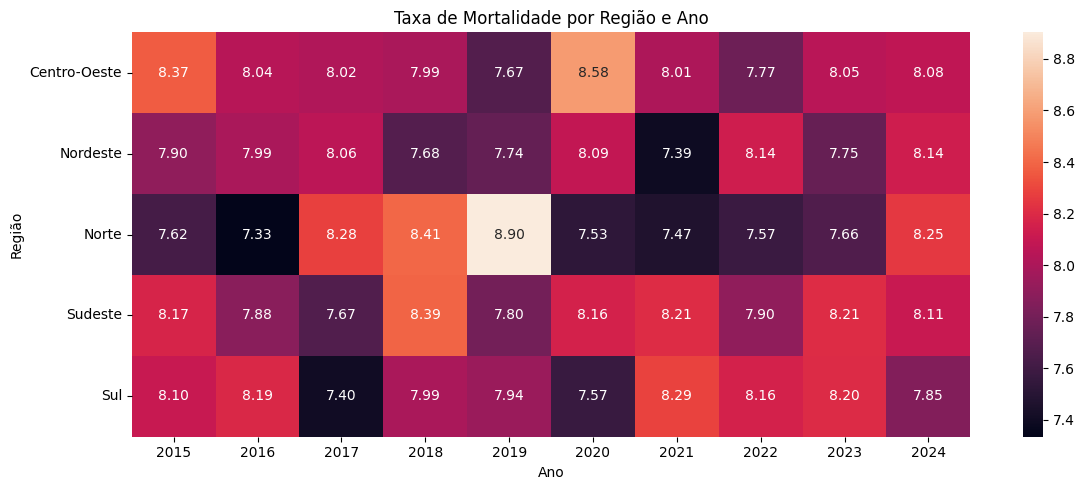

In [27]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    heatmap_mortalidade,
    annot=True,
    fmt=".2f"
)

plt.title("Taxa de Mortalidade por Região e Ano")
plt.xlabel("Ano")
plt.ylabel("Região")

plt.tight_layout()
plt.show()

### 8.5. Vacina x Mortalidade

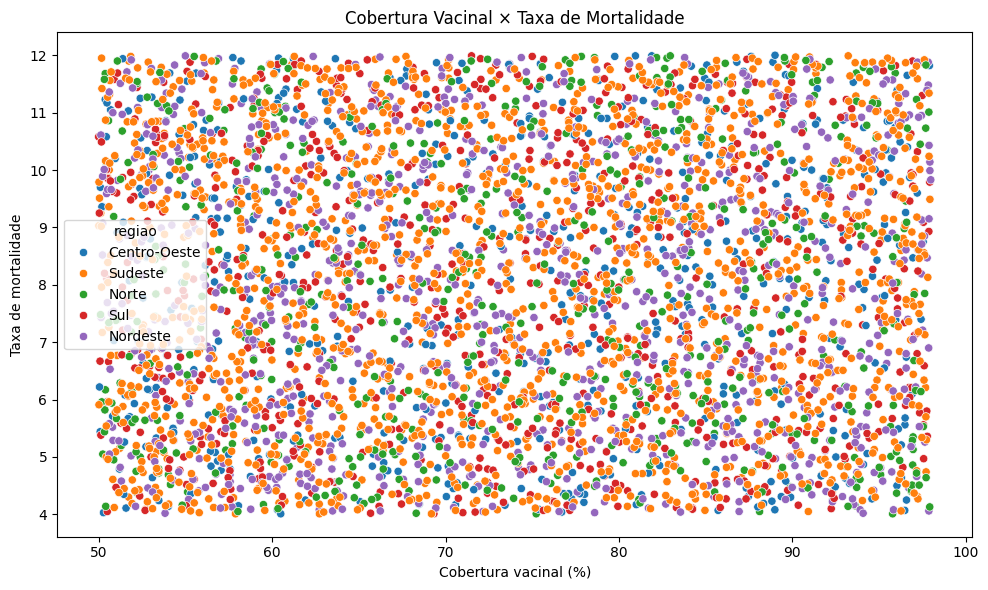

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="cobertura_vacinal",
    y="taxa_mortalidade",
    hue="regiao"
)

plt.title("Cobertura Vacinal × Taxa de Mortalidade")
plt.xlabel("Cobertura vacinal (%)")
plt.ylabel("Taxa de mortalidade")

plt.tight_layout()
plt.show()

### 8.6. Correlação entre os Indicadores

In [29]:
variaveis_numericas = [
    "expectativa_vida",
    "taxa_mortalidade",
    "taxa_internacao",
    "cobertura_vacinal",
    "medicos_por_1000",
    "leitos_hospitalares",
    "casos_doencas_cronicas"
]

matriz_correlacao = df[variaveis_numericas].corr()

matriz_correlacao

,expectativa_vida,taxa_mortalidade,taxa_internacao,cobertura_vacinal,medicos_por_1000,leitos_hospitalares,casos_doencas_cronicas
expectativa_vida,1.000000,-0.002121,0.014861,0.008434,-0.021413,0.006992,-0.002077
taxa_mortalidade,-0.002121,1.000000,-0.011532,0.014525,-0.008418,-0.009092,-0.009217
taxa_internacao,0.014861,-0.011532,1.000000,-0.009121,-0.025009,0.011421,-0.003481
cobertura_vacinal,0.008434,0.014525,-0.009121,1.000000,-0.014928,0.023200,-0.018177
medicos_por_1000,-0.021413,-0.008418,-0.025009,-0.014928,1.000000,-0.015044,-0.020288
leitos_hospitalares,0.006992,-0.009092,0.011421,0.023200,-0.015044,1.000000,0.034029
casos_doencas_cronicas,-0.002077,-0.009217,-0.003481,-0.018177,-0.020288,0.034029,1.000000


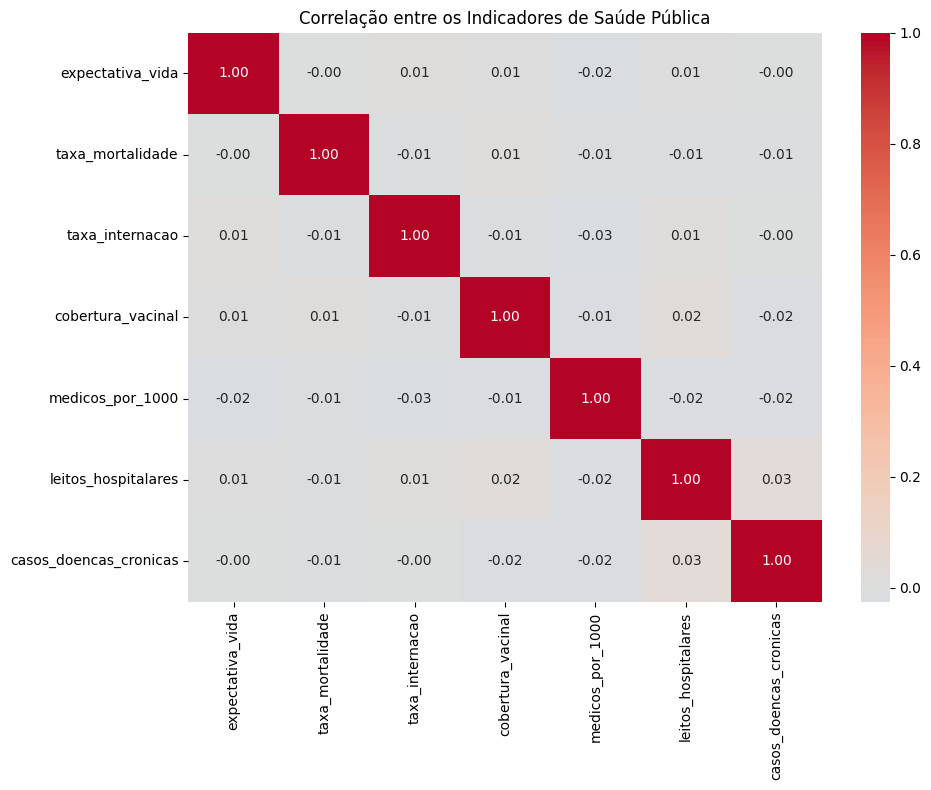

In [30]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlação entre os Indicadores de Saúde Pública")
plt.tight_layout()
plt.show()

### 8.7. Tabelas Dinâmicas

In [31]:
tabela_regiao_ano = pd.pivot_table(
    df,
    index="regiao",
    columns="ano",
    values="taxa_mortalidade",
    aggfunc="mean"
)

tabela_regiao_ano

ano,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
regiao,,,,,,,,,,
Centro-Oeste,8.365500,8.040333,8.017000,7.993000,7.672500,8.580500,8.006000,7.771167,8.046167,8.075167
Nordeste,7.900104,7.993021,8.062083,7.681354,7.743958,8.086771,7.390521,8.135208,7.750729,8.136875
Norte,7.621167,7.334333,8.283500,8.406500,8.903000,7.525333,7.467000,7.574667,7.661333,8.248167
Sudeste,8.173654,7.879231,7.665321,8.389679,7.798718,8.159744,8.208654,7.898141,8.207885,8.107949
Sul,8.104722,8.190000,7.404722,7.992778,7.940556,7.571528,8.285278,8.158472,8.201806,7.853333


In [32]:
tabela_expectativa = pd.pivot_table(
    df,
    index="regiao",
    columns="ano",
    values="expectativa_vida",
    aggfunc="mean"
)

tabela_expectativa

ano,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
regiao,,,,,,,,,,
Centro-Oeste,73.118333,73.490000,73.690000,73.825000,72.838333,73.253333,73.318333,73.876667,73.068333,73.605000
Nordeste,73.182292,73.443750,73.465625,73.734375,73.045833,73.930208,74.071875,72.767708,73.919792,72.635417
Norte,73.425000,73.946667,73.083333,74.385000,73.745000,73.543333,73.571667,73.406667,73.910000,72.673333
Sudeste,73.319231,73.714744,73.816026,73.486538,73.626282,73.684615,73.218590,73.433333,73.647436,73.541026
Sul,73.712500,73.250000,73.720833,73.855556,73.170833,73.397222,73.148611,72.983333,73.015278,73.406944


---
## 8. Persistência dos dados

In [33]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../database/saude_publica.db")

In [34]:
df.to_sql(
    "indicadores_saude",
    con=engine,
    if_exists="replace",
    index=False
)

print("Tabela indicadores de saúde criada no banco SQLite.")

Tabela indicadores de saúde criada no banco SQLite.


In [35]:
df_banco = pd.read_sql(
    "SELECT * FROM indicadores_saude",
    con=engine
)

df_banco.head()

,ano,mes,data,regiao,uf,municipio,expectativa_vida,taxa_mortalidade,taxa_internacao,cobertura_vacinal,...,expectativa_vida_inicial,cobertura_vacinal_inicial,mortalidade_inicial,casos_cronicos_inicial,internacao_inicial,variacao_expectativa_vida,variacao_cobertura_vacinal,variacao_mortalidade,variacao_casos_cronicos,variacao_internacao
0,2015,1,2015-01-01 00:00:00.000000,Centro-Oeste,GO,Aparecida de Goiânia,75.8,6.88,150.76,78.92,...,75.8,78.92,6.88,115696,150.76,0.0,0.00,0.00,0,0.00
1,2015,2,2015-02-01 00:00:00.000000,Centro-Oeste,GO,Aparecida de Goiânia,78.2,8.31,167.91,84.44,...,75.8,78.92,6.88,115696,150.76,2.4,5.52,1.43,15978,17.15
2,2015,3,2015-03-01 00:00:00.000000,Centro-Oeste,GO,Aparecida de Goiânia,71.0,4.08,70.61,88.99,...,75.8,78.92,6.88,115696,150.76,-4.8,10.07,-2.80,-104151,-80.15
3,2015,4,2015-04-01 00:00:00.000000,Centro-Oeste,GO,Aparecida de Goiânia,70.2,9.22,132.83,79.74,...,75.8,78.92,6.88,115696,150.76,-5.6,0.82,2.34,28598,-17.93
4,2015,5,2015-05-01 00:00:00.000000,Centro-Oeste,GO,Aparecida de Goiânia,69.3,9.91,129.64,77.45,...,75.8,78.92,6.88,115696,150.76,-6.5,-1.47,3.03,71225,-21.12


In [36]:
print(f"Registros armazenados no banco: {len(df_banco)}")

Registros armazenados no banco: 4440


---
## 9. Interpretações

### 9.1. Interpretação dos KPIs

Os KPIs analisados fornecem uma visão geral dos indicadores de saúde pública presentes na base. A expectativa média de vida representa um indicador relacionado às condições de vida, enquanto a taxa média de mortalidade permite observar o comportamento geral da mortalidade no conjunto de dados.

A cobertura vacinal representa um indicador preventivo, enquanto a média de leitos hospitalares permite observar a infraestrutura hospitalar disponível nos registros analisados. A análise da criticidade permite identificar os estados que concentram maior quantidade de registros classificados como críticos.

A taxa média de internação também foi analisada, considerando que a base disponibilizada apresenta uma taxa de internação e não uma quantidade absoluta de internações.

### 9.2. Interpretação da evolução temporal

A análise temporal permite observar o comportamento da expectativa de vida ao longo do período de 2015 a 2024. O gráfico apresenta a média anual do indicador, possibilitando identificar a tendência geral observada na base durante o período.

A utilização da média anual permite reduzir a influência das variações individuais dos municípios e visualizar o comportamento agregado do indicador ao longo dos anos.

A evolução observada no gráfico deve ser analisada considerando exclusivamente os dados presentes na base, sem atribuir causas externas às variações identificadas.

### 9.3. Interpretação da mortalidade por estado

A comparação entre estados apresenta diferenças na taxa média de mortalidade observada na base. O gráfico permite identificar os estados que apresentam os maiores e menores valores médios do indicador no período analisado.

Essa comparação evidencia que os indicadores não apresentam necessariamente o mesmo comportamento em todas as unidades federativas representadas na base, permitindo observar diferenças entre os estados.

Os resultados devem ser interpretados como características dos dados analisados, considerando que a base utilizada é um dataset simulado.

### 9.4. Interpretação da infraestrutura hospitalar

A análise da média de leitos hospitalares por estado permite comparar a infraestrutura hospitalar representada na base de dados.

O gráfico evidencia diferenças na quantidade média de leitos entre os estados analisados. Essa visualização permite identificar quais estados apresentam os maiores e menores valores médios de leitos hospitalares no conjunto de dados.

A análise descreve a distribuição do indicador na base e não estabelece, isoladamente, uma relação entre quantidade de leitos e qualidade do atendimento em saúde.

### 9.5. Interpretação da mortalidade por região e ano

O heatmap permite analisar simultaneamente a taxa média de mortalidade por região e por ano.

A representação facilita a identificação de períodos e regiões que apresentam valores mais elevados ou mais baixos do indicador, permitindo observar diferenças regionais e sua evolução ao longo do período de 2015 a 2024.

Essa visualização complementa o gráfico por estado, pois permite observar o comportamento agregado das regiões ao longo do tempo.

### 9.6. Interpretação da relação entre vacinação e mortalidade

A relação entre cobertura vacinal e taxa de mortalidade foi analisada por meio do gráfico de dispersão e da matriz de correlação.

O gráfico de dispersão permite observar a distribuição dos registros e verificar visualmente se existe um padrão de alinhamento entre as duas variáveis. A matriz de correlação complementa essa análise ao apresentar numericamente a intensidade e a direção da relação linear entre os indicadores.

Na base analisada, a correlação entre cobertura vacinal e taxa de mortalidade é próxima de zero, indicando ausência de uma relação linear significativa entre essas duas variáveis no conjunto de dados analisado.

Esse resultado deve ser interpretado como uma característica da relação observada na base, não como uma afirmação de que vacinação e mortalidade não possuem qualquer relação, uma vez que a análise realizada considera especificamente a associação linear entre as variáveis.

### 9.7. Interpretação da matriz de correlação

A matriz de correlação permite comparar as relações lineares entre os diferentes indicadores quantitativos presentes na base.

Os valores próximos de 1 indicam relações lineares positivas mais fortes, enquanto valores próximos de -1 indicam relações lineares negativas mais fortes. Valores próximos de zero indicam pouca ou nenhuma relação linear entre as variáveis.

A visualização permite identificar quais pares de indicadores apresentam maior associação linear no conjunto de dados, servindo como complemento às análises individuais realizadas anteriormente.

---
## 10. Conclusão

O projeto permitiu realizar uma análise exploratória e visual dos indicadores de saúde pública presentes na base de dados simulada, considerando o período de 2015 a 2024.

A análise envolveu a preparação dos dados, verificação de sua estrutura e consistência, criação de atributos derivados e cálculo de indicadores relacionados à expectativa de vida, mortalidade, vacinação, criticidade, infraestrutura hospitalar e internações.

As visualizações permitiram analisar a evolução temporal dos indicadores, comparar estados e regiões, observar a distribuição da mortalidade, analisar a infraestrutura hospitalar e investigar a relação entre cobertura vacinal e taxa de mortalidade.

A utilização da matriz de correlação complementou o gráfico de dispersão, permitindo avaliar as relações lineares entre os indicadores quantitativos. No caso específico da cobertura vacinal e da taxa de mortalidade, a correlação observada foi próxima de zero, não sendo identificado um padrão linear relevante entre as duas variáveis na base analisada.

A persistência dos dados em banco SQLite, utilizando SQLAlchemy, também foi incorporada ao projeto, permitindo armazenar e consultar os dados analisados.

De forma geral, o projeto possibilitou transformar a base de dados em informações organizadas por meio de indicadores, tabelas e visualizações, facilitando a identificação de diferenças temporais, regionais e estaduais presentes no conjunto de dados.

Como os dados utilizados são simulados, as conclusões apresentadas estão restritas ao comportamento observado nessa base e não devem ser utilizadas para representar diretamente a situação real da saúde pública brasileira.